(200, 2176)
(200,)
(200, 1344)
(200,)
(200, 2176)
(200,)
(200, 1344)
(200,)


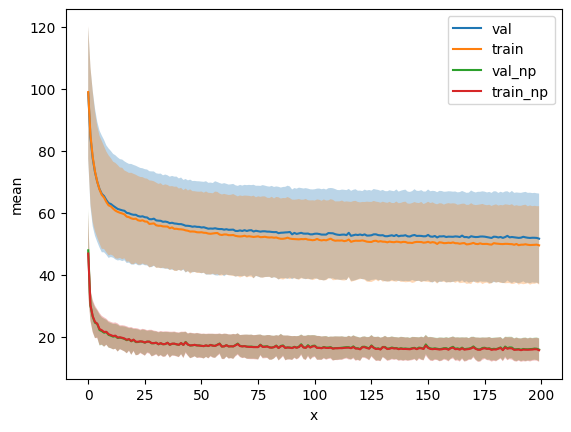

In [7]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

val_scores_path = "/home/pavel/data/goal-misgen/tmp/val_scores.npy"
# val_scores_path = "/home/pavel/code/goal-misgen/yrc-bench-fork/experiments/debug_ood/val_scores.npy"
training_scores_path = "/home/pavel/code/goal-misgen/yrc-bench-fork/experiments/debug_ood/training_scores.npy"

val_scores = np.load(val_scores_path)
training_scores = np.load(training_scores_path)

base_path = Path("/home/pavel/data/goal-misgen/tmp/")
score_paths = [
    ("val", base_path / "val_scores_3.npy"),
    ("train", base_path / "training_scores_3.npy"),
    ("val_np", base_path / "val_scores_no_preprocess.npy"),
    ("train_np", base_path / "training_scores_no_preprocess.npy"),
]

scores = []
for name, score in score_paths:
    scores.append((np.load(score), name))

for scores, name in scores: #, (training_scores, "train")]:

    print(scores.shape)

    mean_scores = np.mean(scores, axis=1)

    x = range(mean_scores.shape[0])
    std_scores = np.std(scores, axis=1)
    df = pd.DataFrame({
        "x": x,
        # "val_scores": val_scores,
        "mean": mean_scores,
        "std": std_scores
    })

    print(mean_scores.shape)

    # Plot means over episodes.
    sns.lineplot(
        data=df,
        x="x",
        y="mean",
        label=name,
    )

    plt.fill_between(df["x"], df["mean"] - df["std"], df["mean"] + df["std"], alpha=0.3)




Ask for help percentage: [0.9999735158269418, 0.8888830035170981, 0.777771303868808, 0.6666596042205178, 0.5555532014068393, 0.4444415017585491, 0.33331920844103563, 0.22221810246196871, 0.11110110597906692, 0.0]
Thresholds: [3.34451324e-05 5.53818303e-04 6.75899442e-04 7.95919448e-04
 9.30185326e-04 1.10293319e-03 1.35385687e-03 1.82971521e-03
 2.73777032e-03 2.95277648e-02]
Ask for help percentage: [0.9999258443154371, 0.8888830035170981, 0.7777554133649731, 0.6666543073859061, 0.5555267172337811, 0.4444415017585491, 0.3333245052756473, 0.2222128056273571, 0.11111169964829018, 0.0]
Thresholds: [4.37383551e-06 1.34508387e-04 1.75438880e-04 2.14663101e-04
 2.59084249e-04 3.14561214e-04 3.87276697e-04 5.12578292e-04
 7.53162073e-04 3.33134495e-02]
Ask for help percentage: [0.9999258443154371, 0.8888883003517098, 0.7777501165303614, 0.6666384168820713, 0.555542607737616, 0.4444415017585491, 0.33333509894487057, 0.2222128056273571, 0.11111169964829018, 0.0]
Thresholds: [3.09185998e-05 4.5

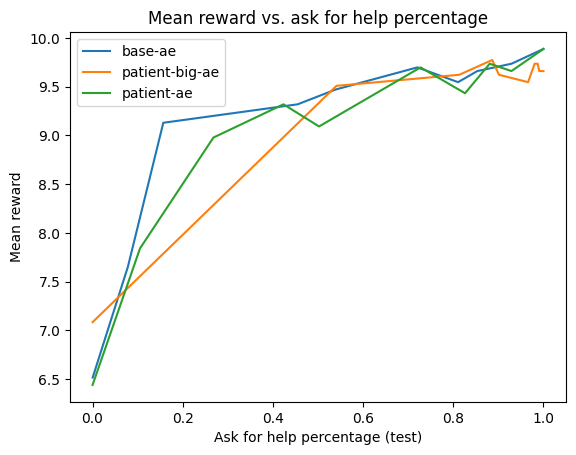

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

base_path = Path("/home/pavel/data/goal-misgen/tmp")

eval_path = base_path / "08-eval" 

evals = ["base-ae", "patient-big-ae", "patient-ae"]

for eval in evals:

    data_path = eval_path / f"{eval}.npz"

    eval_data = np.load(data_path, allow_pickle=True)

    results = eval_data["results"]

    thresholds = eval_data["thresholds"]

    split = "test"

    mean_rewards = []
    std_rewards = []
    afh_percentage = []

    for result in results:
        mean_rewards.append(result[split]["reward_mean"])
        std_rewards.append(result[split]["reward_std"])
        afh_percentage.append(result[split]["action_1_frac"])

    # Calculate ask for help precentage for each threshold.
    train_ood_percentage = []

    for threshold in thresholds:
        num_larger = np.sum(eval_data["training_scores"] > threshold)
        train_ood_percentage.append(num_larger / len(eval_data["training_scores"]))


    print(f"Ask for help percentage: {train_ood_percentage}")

    print(f"Thresholds: {thresholds}")

    # Plot lineplot using seaborn.
    sns.lineplot(x=afh_percentage, y=mean_rewards, label=eval)

plt.xlabel("Ask for help percentage (test)")
plt.ylabel("Mean reward")
plt.title("Mean reward vs. ask for help percentage")
plt.legend()
plt.show()

# Plot lineplot using matplotlib.
# plt.plot(thresholds, mean_rewards)
# plt.fill_between(thresholds, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.5)
# plt.show()



# print(eval_data["thresholds"])

# print(eval_data["scores"])